In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

## Example 1: fake data for demonstration

In [36]:
fake_data = {
    "job_skills":["python", "sql", "java", "c++", "c#", "javascript", "html", "css", "php", "ruby"],
    "skill_count":[30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
    "skill_pay":[100, 90, 80, 70, 60, 50, 40, 30, 20, 10],
}

fake_dataframe = pd.DataFrame(fake_data)
fake_dataframe

,job_skills,skill_count,skill_pay
0,python,30,100
1,sql,25,90
2,java,20,80
3,c++,15,70
4,c#,10,60
5,javascript,5,50
6,html,4,40
7,css,3,30
8,php,2,20
9,ruby,1,10


## Example 2: job skills insights

In [ ]:
# filter dataframe to have only data analyst job postings
df_da = df.loc[
    df["job_title_short"] == "Data Analyst"
].reset_index(drop=True).copy()

In [27]:
# filter only necessary columns for analysis
df_da_filtered = df_da.loc[
    :,
    ["job_title_short", "salary_year_avg", "job_skills"]
].reset_index(drop=True)

In [28]:
# exploding
df_da_exploded = df_da_filtered.explode("job_skills")

In [29]:
df_da_exploded

,job_title_short,salary_year_avg,job_skills
0,Data Analyst,NaN,r
0,Data Analyst,NaN,python
0,Data Analyst,NaN,sql
0,Data Analyst,NaN,nosql
0,Data Analyst,NaN,power bi
...,...,...,...
196073,Data Analyst,NaN,azure
196074,Data Analyst,NaN,sas
196074,Data Analyst,NaN,sas
196074,Data Analyst,NaN,sql


In [ ]:
# aggregation
final_df = df_da_exploded.groupby("job_skills").agg(
    median_yearly_salary=("salary_year_avg", "median"),
    job_postings_count=("job_title_short", "size")
).sort_values(by="job_postings_count", ascending=False).head(10)

,median_yearly_salary,job_postings_count
job_skills,,
sql,92500.0,92428
excel,84479.0,66860
python,98500.0,57190
tableau,95000.0,46455
power bi,90000.0,39380
r,92527.5,29996
sas,90000.0,27998
powerpoint,85000.0,13822
word,80000.0,13562


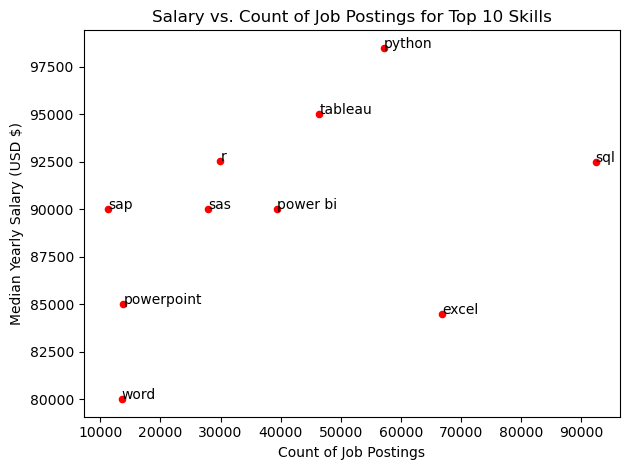

In [ ]:
# plotting
final_df.plot(kind="scatter", x="job_postings_count", y="median_yearly_salary", color="red")
plt.xlabel("Count of Job Postings")
plt.ylabel("Median Yearly Salary (USD $)")
plt.title("Salary vs. Count of Job Postings for Top 10 Skills")

# loop for label customization
for i, skill in enumerate(final_df.index):
    plt.text(x=final_df["job_postings_count"].iloc[i], y=final_df["median_yearly_salary"].iloc[i], s=skill)

plt.tight_layout()
plt.show()